In [ ]:
import os
current_dir = os.path.basename(os.getcwd())
if not current_dir.startswith('show-and-tell'):
    os.chdir('..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from demo_utils import show_anns
import random

## Load Image

In [3]:
# Pick one of the follwing: 'eiffel', 'dog', 'boxes', 'drawing'
image_name = random.choice(['eiffel', 'dog', 'boxes', 'drawing'])

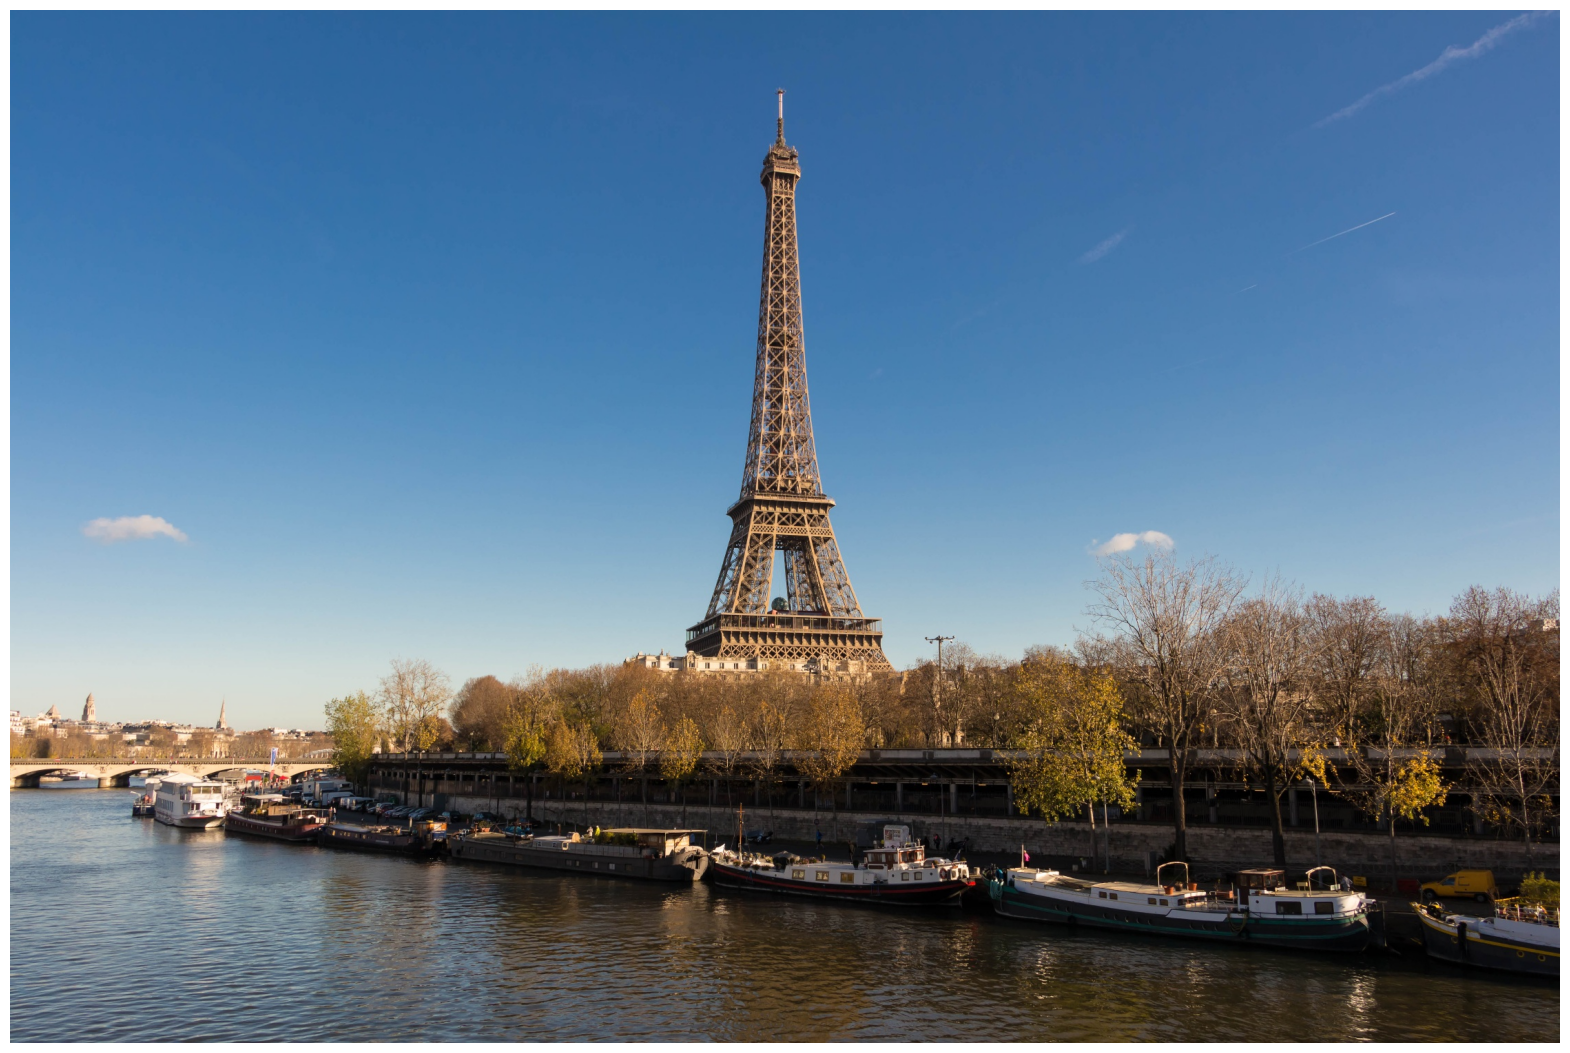

In [4]:
image_paths = {'eiffel': 'demos/images/sa_574.jpg',
               'dog': 'demos/images/dog.jpg',
               'boxes': 'demos/images/boxes.jpg',
               'drawing': 'demos/images/drawing.jpg'}

image = cv2.imread(image_paths[image_name])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(20,20))
plt.imshow(image)
plt.axis('off')
plt.show()

## Generate ROI masks with Segment Anything Model (SAM)

Download the [ViT-B SAM model checkpoint](https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth) and place it under `segment_anything/checkpoint` folder

In [5]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

sam_checkpoint = "segment_anything/checkpoint/sam_vit_b_01ec64.pth"
model_type = "vit_b"
device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
mask_generator = SamAutomaticMaskGenerator(sam)

In [6]:
# filter out small masks
area_th = 3000
masks = mask_generator.generate(image)
new_masks = []
for mask in masks:
    if mask['area'] > area_th:
        new_masks.append(mask)

In [7]:
sam_masks = {'eiffel': (1, 2),
             'dog': (0, 6),
             'boxes': (40, 49),
             'drawing': (0, 9)}

selected_masks = [new_masks[sam_masks[image_name][0]], new_masks[sam_masks[image_name][1]]] 

Show selected ROI masks

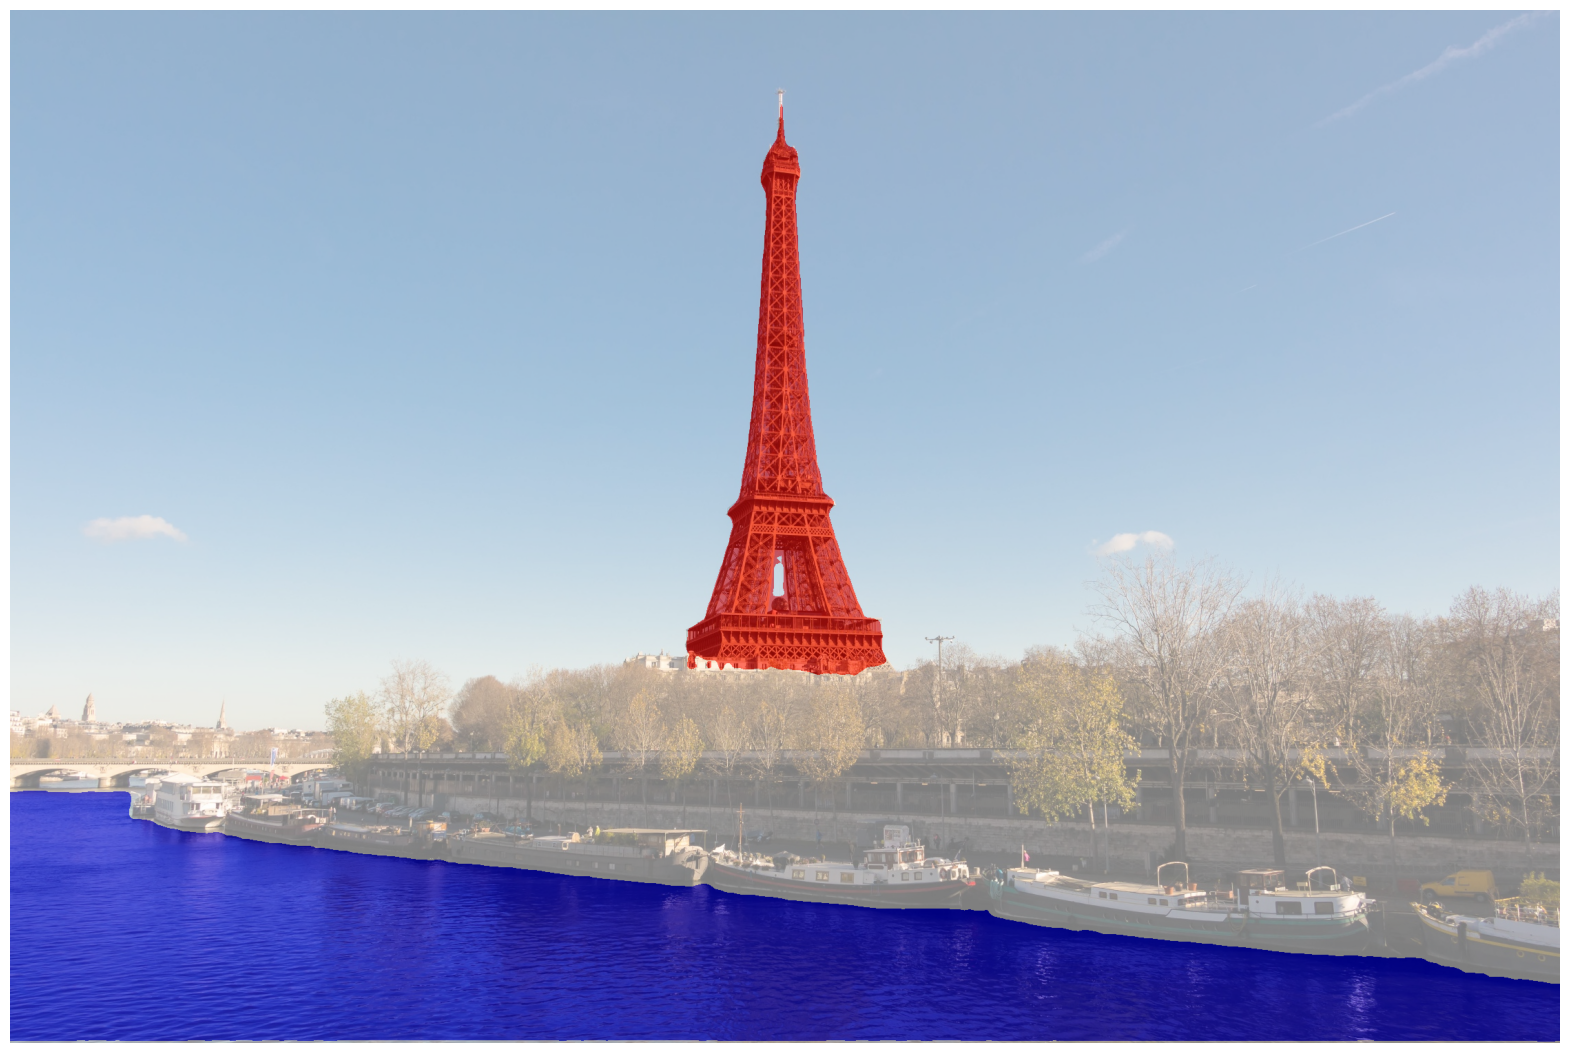

In [8]:
plt.figure(figsize=(20,20))
plt.imshow(image)
show_anns(selected_masks)
plt.axis('off')
plt.show()

## Explain Anything
Ask the model to explain what concepts it recognizes in the red and blue regions

In [9]:
import torch
import data_utils
import cbm
from plots import *
from demo_utils import bar2
from data_utils import get_resnet_imagenet_preprocess
from skimage.transform import resize
from PIL import Image

In [10]:
# Set path to the correct model dir
load_dir = "models/imagenet"
device = "cpu"
dataset = "imagenet"
backbone = "resnet50_imagenet"
target_preprocess = data_utils.get_resnet_imagenet_preprocess
model = cbm.load_cbm(load_dir, backbone, device)

In [11]:
cls_file = data_utils.LABEL_FILES[dataset]

with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

preprocess = get_resnet_imagenet_preprocess()
proc_image = preprocess(Image.fromarray(image))

In [12]:
# Configuration
COLORS = [
    [0.0, 0.0, 1.0, 0.5],  # Blue with transparency
    [1.0, 0.0, 0.0, 0.5],  # Red with transparency
]
CONCEPT_THRESHOLD = 0.005
MAX_CONCEPTS_DISPLAY = 3
IMAGE_SIZE = (224, 224)

def process_concept_maps(concept_maps, roi_mask, target_size=IMAGE_SIZE):
    """Process concept maps and calculate ROI activations."""
    concept_act_roi = np.zeros((1, concept_maps.shape[1]))
    
    for k in range(concept_maps.shape[1]):
        concept_map = concept_maps[0, k, :, :].cpu().numpy()
        concept_map_resized = resize(
            concept_map, 
            target_size, 
            order=1, 
            mode='reflect', 
            anti_aliasing=True
        )
        concept_act_roi[0, k] = np.mean(concept_map_resized[roi_mask > 0])
    
    return concept_act_roi

def generate_feature_names(concept_activations, concepts):
    """Generate feature names with NOT prefix for negative activations."""
    return [
        ("NOT " if activation < 0 else "") + concept 
        for activation, concept in zip(concept_activations, concepts)
    ]

def calculate_display_count(values, threshold=CONCEPT_THRESHOLD, max_display=MAX_CONCEPTS_DISPLAY):
    """Calculate how many concepts to display based on threshold."""
    significant_concepts = int(sum(abs(values) > threshold)) + 1
    return min(significant_concepts, max_display)

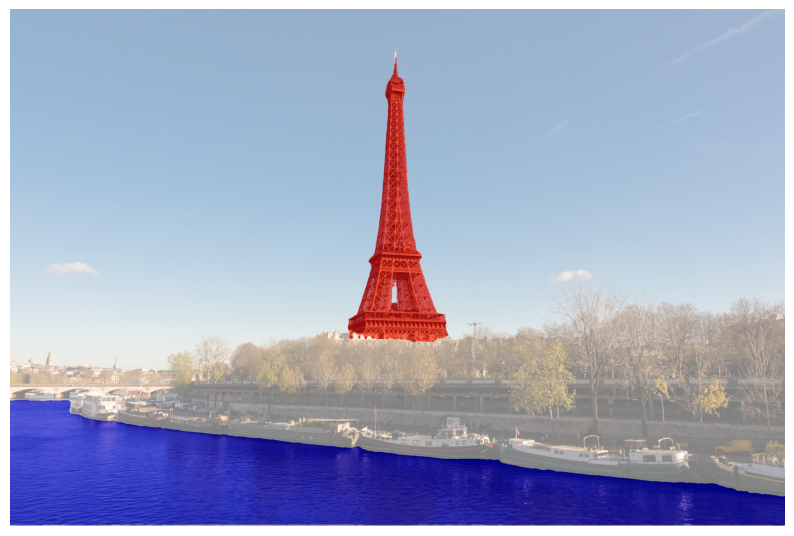

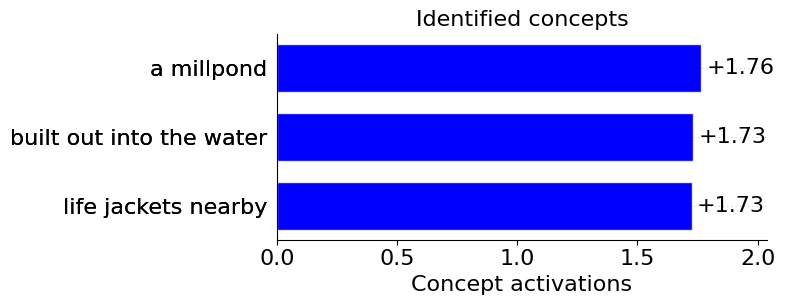

<Figure size 640x480 with 0 Axes>

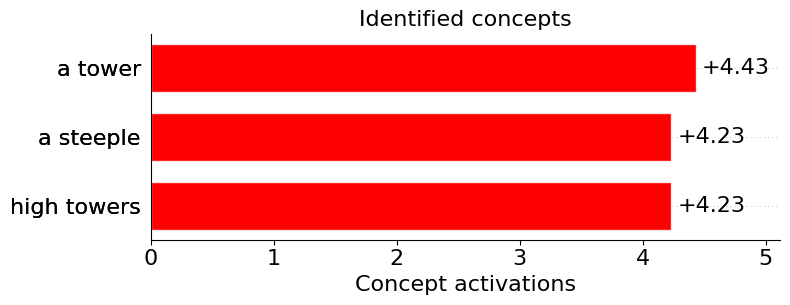

<Figure size 640x480 with 0 Axes>

In [13]:
# Display initial image with annotations
plt.figure(figsize=(10, 10))
plt.imshow(image)
show_anns(selected_masks)
plt.axis('off')
plt.show()

# Process each mask
with torch.no_grad():
    # Pre-process image
    x = proc_image.unsqueeze(0).to(device)
    outputs, concept_act, concept_maps = model(x)
    
    # Calculate top predictions and confidence
    top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=2)
    confidence = torch.nn.functional.softmax(outputs[0], dim=0)
    
    for i, mask in enumerate(selected_masks):
        # Resize mask to match processed image dimensions
        roi_mask = resize(mask['segmentation'], proc_image.shape[1:])
        
        # Process concept maps for this ROI
        concept_act_roi = process_concept_maps(concept_maps, roi_mask)
        
        # Generate visualization data
        values = concept_act_roi[0]
        feature_names = generate_feature_names(values, concepts)
        max_display = calculate_display_count(values)
        
        # Create bar plot
        bar2(
            values, 
            feature_names, 
            max_display=max_display, 
            title="Identified concepts", 
            fontsize=16, 
            bar_colors_rgba=COLORS[i % len(COLORS)][:-1],
            label_colors_rgba=[0, 0, 0]
        )
        plt.tight_layout()
        plt.show()